# Solution - Exercice 2 : Tokenization et Vectorisation


## Imports et données

In [1]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from nltk.corpus import stopwords

critiques = [
    "Ce film est absolument fantastique! La cinématographie est magnifique.",
    "Quel ennui... le scénario est prévisible et les acteurs sans charisme.",
    "Un excellent film! Très émouvant et bien réalisé. À voir!",
    "Décevant. Les effets spéciaux sont bons mais l'histoire manque de profondeur.",
    "Masterpiece! Un incontournable. Brillant du début à la fin.",
    "Horrible film. Perte de temps totale. Pas recommandé."
]
labels = np.array([1, 0, 1, 0, 1, 0])

for i, (critique, label) in enumerate(zip(critiques, labels)):
    sentiment = "positif" if label == 1 else "négatif"
    print(f"{i+1}. [{sentiment}] {critique[:60]}...")

1. [positif] Ce film est absolument fantastique! La cinématographie est m...
2. [négatif] Quel ennui... le scénario est prévisible et les acteurs sans...
3. [positif] Un excellent film! Très émouvant et bien réalisé. À voir!...
4. [négatif] Décevant. Les effets spéciaux sont bons mais l'histoire manq...
5. [positif] Masterpiece! Un incontournable. Brillant du début à la fin....
6. [négatif] Horrible film. Perte de temps totale. Pas recommandé....


## Tâche 1 : Count Vectorizer

In [2]:
french_stopwords = stopwords.words("french")
# Configuration de CountVectorizer
cv = CountVectorizer(
    lowercase=True,
    stop_words=french_stopwords,
    min_df=1,
    max_features=100
)

# Fit et transform
X_bow = cv.fit_transform(critiques)

print(f"Shape: {X_bow.shape} (documents x features)")
print(f"Densité: {X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]) * 100:.2f}%")
print(f"\nVocabulaire (25 premiers termes):")
feature_names = cv.get_feature_names_out()
print(feature_names[:25])

Shape: (6, 35) (documents x features)
Densité: 17.62%

Vocabulaire (25 premiers termes):
['absolument' 'acteurs' 'bien' 'bons' 'brillant' 'charisme'
 'cinématographie' 'début' 'décevant' 'effets' 'ennui' 'excellent'
 'fantastique' 'film' 'fin' 'histoire' 'horrible' 'incontournable'
 'magnifique' 'manque' 'masterpiece' 'perte' 'profondeur' 'prévisible'
 'quel']


## Tâche 2 : Analyse du vocabulaire

film: 3 occurrences
voir: 1 occurrences
émouvant: 1 occurrences
très: 1 occurrences
totale: 1 occurrences
spéciaux: 1 occurrences
temps: 1 occurrences
sans: 1 occurrences
réalisé: 1 occurrences
recommandé: 1 occurrences


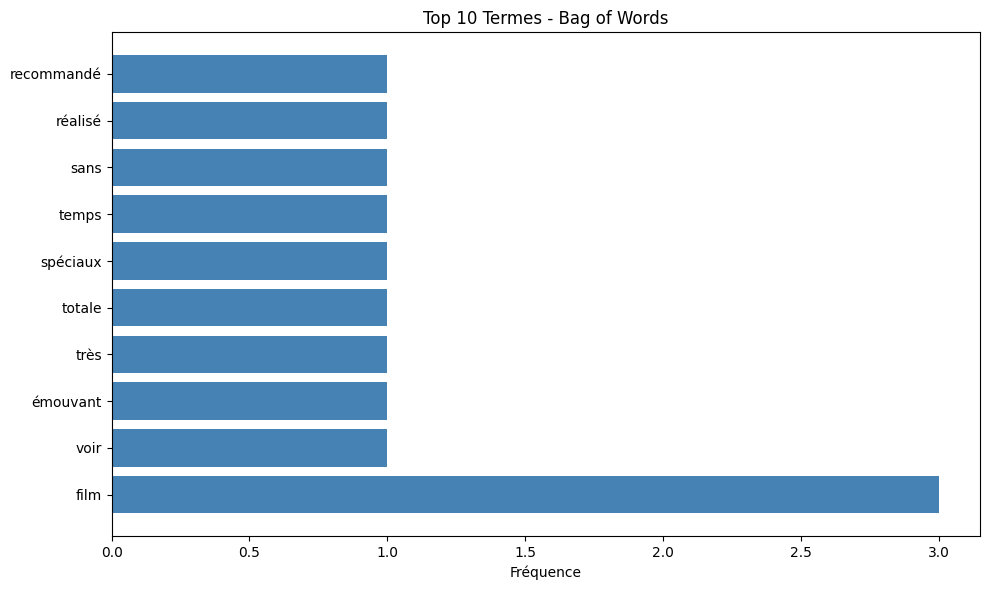

In [3]:
# Calculer la fréquence des termes
X_bow_dense = X_bow.toarray()
term_freq = X_bow_dense.sum(axis=0)

# Top 10 termes
top_indices = np.argsort(term_freq)[-10:][::-1]
top_terms = feature_names[top_indices]
top_freqs = term_freq[top_indices]

for term, freq in zip(top_terms, top_freqs):
    print(f"{term}: {int(freq)} occurrences")

# Visualisation
plt.figure(figsize=(10, 6))
plt.barh(top_terms, top_freqs, color='steelblue')
plt.xlabel('Fréquence')
plt.title('Top 10 Termes - Bag of Words')
plt.tight_layout()
plt.show()

## Tâche 3 : TF-IDF Vectorizer

In [4]:
# Configuration TF-IDF
tf = TfidfVectorizer(
    lowercase=True,
    stop_words=french_stopwords,
    min_df=1,
    max_features=100
)

X_tfidf = tf.fit_transform(critiques)

print(f"Shape: {X_tfidf.shape}")
print(f"Densité: {X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]) * 100:.2f}%")

# Comparaison premier document
X_tfidf_dense = X_tfidf.toarray()
print(f"\nPremier document - Scores TF-IDF:")
doc1_scores = X_tfidf_dense[0]
nonzero_idx = np.where(doc1_scores > 0)[0]
for idx in nonzero_idx[:10]:
    print(f"{feature_names[idx]}: {doc1_scores[idx]:.4f}")

Shape: (6, 35)
Densité: 17.62%

Premier document - Scores TF-IDF:
absolument: 0.4725
cinématographie: 0.4725
fantastique: 0.4725
film: 0.3271
magnifique: 0.4725


## Tâche 4 : Densité et Sparsité

In [5]:
# Calculer densité
density_bow = X_bow.nnz / (X_bow.shape[0] * X_bow.shape[1]) * 100
density_tfidf = X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]) * 100

print(f"\nBag of Words:")
print(f"  Densité: {density_bow:.2f}%")
print(f"  Sparsité: {100 - density_bow:.2f}%")
print(f"  Non-zéros: {X_bow.nnz} / {X_bow.shape[0] * X_bow.shape[1]}")

print(f"\nTF-IDF:")
print(f"  Densité: {density_tfidf:.2f}%")
print(f"  Sparsité: {100 - density_tfidf:.2f}%")
print(f"  Non-zéros: {X_tfidf.nnz} / {X_tfidf.shape[0] * X_tfidf.shape[1]}")


Bag of Words:
  Densité: 17.62%
  Sparsité: 82.38%
  Non-zéros: 37 / 210

TF-IDF:
  Densité: 17.62%
  Sparsité: 82.38%
  Non-zéros: 37 / 210


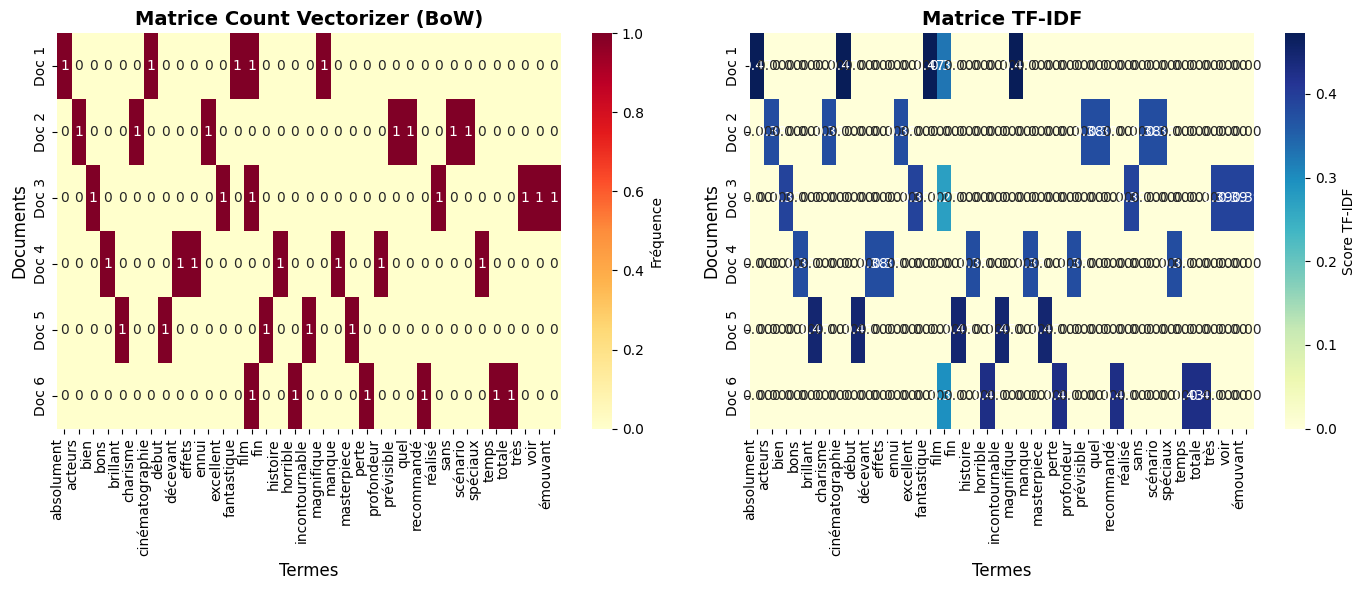

In [6]:
# Visualisation heatmap de la sparsité
plt.figure(figsize=(14, 6))

# Heatmap pour CountVectorizer
plt.subplot(1, 2, 1)
sns.heatmap(X_bow.toarray(), annot=True, fmt='.0f', cmap='YlOrRd',
            xticklabels=cv.get_feature_names_out(),
            yticklabels=[f'Doc {i+1}' for i in range(len(critiques))],
            cbar_kws={'label': 'Fréquence'})
plt.title('Matrice Count Vectorizer (BoW)', fontsize=14, fontweight='bold')
plt.xlabel('Termes', fontsize=12)
plt.ylabel('Documents', fontsize=12)
plt.xticks(rotation=90, ha='right')

# Heatmap pour TF-IDF
plt.subplot(1, 2, 2)
sns.heatmap(X_tfidf.toarray(), annot=True, fmt='.2f', cmap='YlGnBu',
            xticklabels=tf.get_feature_names_out(),
            yticklabels=[f'Doc {i+1}' for i in range(len(critiques))],
            cbar_kws={'label': 'Score TF-IDF'})
plt.title('Matrice TF-IDF', fontsize=14, fontweight='bold')
plt.xlabel('Termes', fontsize=12)
plt.ylabel('Documents', fontsize=12)
plt.xticks(rotation=90, ha='right')

plt.tight_layout()
plt.show()

## Tâche 5 : L1 vs L2 Normalization

In [7]:
# TF-IDF avec L1
tf_l1 = TfidfVectorizer(
    norm='l1',
    lowercase=True,
    stop_words=french_stopwords,
    min_df=1,
    max_features=100
)

X_tfidf_l1 = tf_l1.fit_transform(critiques).toarray()

# TF-IDF avec L2 (défaut)
tf_l2 = TfidfVectorizer(
    norm='l2',
    lowercase=True,
    stop_words=french_stopwords,
    min_df=1,
    max_features=100
)

X_tfidf_l2 = tf_l2.fit_transform(critiques).toarray()

# Comparer les 3 premiers documents
for doc_idx in range(3):
    print(f"\nDocument {doc_idx + 1}:")
    print(f"  L1 norm (somme): {X_tfidf_l1[doc_idx]}")
    print(f"  L2 norm (euclidienne): {X_tfidf_l2[doc_idx]}")


Document 1:
  L1 norm (somme): [0.21311454 0.         0.         0.         0.         0.
 0.21311454 0.         0.         0.         0.         0.
 0.21311454 0.14754184 0.         0.         0.         0.
 0.21311454 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]
  L2 norm (euclidienne): [0.47249269 0.         0.         0.         0.         0.
 0.47249269 0.         0.         0.         0.         0.
 0.47249269 0.32711256 0.         0.         0.         0.
 0.47249269 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.        ]

Document 2:
  L1 norm (somme): [0.         0.14285714 0.         0.         0.         0.14285714
 0.         0.         0.         0.         0.14285714 0.
 0.         0.         0.         0.         0.         0.
 0.         0.        

## Tâche 6 : Pipeline pratique avec classifieur

In [8]:
# Split train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, labels, test_size=0.2, random_state=42
)

# Entraîner Logistic Regression
clf = LogisticRegression(random_state=42, max_iter=1000)
clf.fit(X_train, y_train)

# Évaluation
y_pred = clf.predict(X_test)

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred):.4f}")

Accuracy:  0.5000
Precision: 0.0000
Recall:    0.0000
F1-score:  0.0000


c:\Users\Administrateur\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## bonus

In [9]:
# Test avec différentes valeurs de max_features
max_features_values = [5, 10, 20, 50]

for max_feat in max_features_values:
    vectorizer = TfidfVectorizer(
        lowercase=True,
        stop_words=french_stopwords,
        max_features=max_feat
    )
    X = vectorizer.fit_transform(critiques)
    vocab = vectorizer.get_feature_names_out()
    
    print(f"\nmax_features = {max_feat}:")
    print(f"  Vocabulaire: {vocab}")
    print(f"  Shape: {X.shape}")


max_features = 5:
  Vocabulaire: ['absolument' 'acteurs' 'bien' 'brillant' 'film']
  Shape: (6, 5)

max_features = 10:
  Vocabulaire: ['absolument' 'acteurs' 'bien' 'bons' 'brillant' 'charisme'
 'cinématographie' 'début' 'décevant' 'film']
  Shape: (6, 10)

max_features = 20:
  Vocabulaire: ['absolument' 'acteurs' 'bien' 'bons' 'brillant' 'charisme'
 'cinématographie' 'début' 'décevant' 'effets' 'ennui' 'excellent'
 'fantastique' 'film' 'fin' 'histoire' 'horrible' 'incontournable'
 'magnifique' 'manque']
  Shape: (6, 20)

max_features = 50:
  Vocabulaire: ['absolument' 'acteurs' 'bien' 'bons' 'brillant' 'charisme'
 'cinématographie' 'début' 'décevant' 'effets' 'ennui' 'excellent'
 'fantastique' 'film' 'fin' 'histoire' 'horrible' 'incontournable'
 'magnifique' 'manque' 'masterpiece' 'perte' 'profondeur' 'prévisible'
 'quel' 'recommandé' 'réalisé' 'sans' 'scénario' 'spéciaux' 'temps'
 'totale' 'très' 'voir' 'émouvant']
  Shape: (6, 35)


## bonus 2 : comparaison

In [10]:
# Unigrammes seulement
vectorizer_unigrams = TfidfVectorizer(
    lowercase=True,
    stop_words=french_stopwords,
    ngram_range=(1, 1),
    max_features=30
)
X_unigrams = vectorizer_unigrams.fit_transform(critiques)
vocab_unigrams = vectorizer_unigrams.get_feature_names_out()

# Unigrammes + Bigrammes
vectorizer_bigrams = TfidfVectorizer(
    lowercase=True,
    stop_words=french_stopwords,
    ngram_range=(1, 2),
    max_features=30
)
X_bigrams = vectorizer_bigrams.fit_transform(critiques)
vocab_bigrams = vectorizer_bigrams.get_feature_names_out()

print(f"\nUnigrammes seulement (1, 1):")
print(f"  Vocabulaire ({len(vocab_unigrams)} termes): {vocab_unigrams[:15]}")
print(f"  Shape: {X_unigrams.shape}")

print(f"\nUnigrammes + Bigrammes (1, 2):")
print(f"  Vocabulaire ({len(vocab_bigrams)} termes): {vocab_bigrams[:15]}")
print(f"  Shape: {X_bigrams.shape}")

# Identifier les bigrammes


Unigrammes seulement (1, 1):
  Vocabulaire (30 termes): ['absolument' 'acteurs' 'bien' 'bons' 'brillant' 'charisme'
 'cinématographie' 'début' 'décevant' 'effets' 'ennui' 'excellent'
 'fantastique' 'film' 'fin']
  Shape: (6, 30)

Unigrammes + Bigrammes (1, 2):
  Vocabulaire (30 termes): ['absolument' 'absolument fantastique' 'acteurs' 'acteurs sans' 'bien'
 'bien réalisé' 'bons' 'bons histoire' 'brillant' 'brillant début'
 'charisme' 'cinématographie' 'cinématographie magnifique' 'début'
 'début fin']
  Shape: (6, 30)


## bonus 3 : 

In [11]:
import re
from collections import Counter

def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

def compute_tf(document):
    """Calcule la fréquence des termes (TF) dans un document"""
    tokens = tokenize(document)
    tf = Counter(tokens)
    # Normalisation par le nombre total de termes
    total = len(tokens)
    return {term: count / total for term, count in tf.items()}

def compute_idf(documents):
    """Calcule l'IDF (Inverse Document Frequency) pour tous les termes"""
    N = len(documents)
    idf = {}
    
    # Compter dans combien de documents chaque terme apparaît
    all_terms = set()
    for doc in documents:
        all_terms.update(tokenize(doc))
    
    for term in all_terms:
        doc_count = sum(1 for doc in documents if term in tokenize(doc))
        idf[term] = np.log((N + 1) / (doc_count + 1)) + 1  # smooth IDF
    
    return idf

def compute_tfidf(documents):
    """Calcule TF-IDF pour une collection de documents"""
    idf = compute_idf(documents)
    tfidf_matrix = []
    
    for doc in documents:
        tf = compute_tf(doc)
        tfidf_doc = {term: tf_val * idf.get(term, 0) for term, tf_val in tf.items()}
        tfidf_matrix.append(tfidf_doc)
    
    return tfidf_matrix, idf

# Test sur notre corpus
tfidf_custom, idf_custom = compute_tfidf(critiques)

for term, score in sorted(tfidf_custom[0].items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f"  {term}: {score:.4f}")

print(f"\nIDF de quelques termes:")
sample_terms = list(idf_custom.keys())[:10]
for term in sample_terms:
    print(f"  {term}: {idf_custom[term]:.4f}")

  est: 0.4105
  ce: 0.2503
  absolument: 0.2503
  fantastique: 0.2503
  cinématographie: 0.2503
  magnifique: 0.2503
  la: 0.2053
  film: 0.1733

IDF de quelques termes:
  fantastique: 2.2528
  bons: 2.2528
  magnifique: 2.2528
  totale: 2.2528
  perte: 2.2528
  absolument: 2.2528
  sans: 2.2528
  effets: 2.2528
  histoire: 2.2528
  et: 1.8473


## Bonus 4 :

In [12]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score

# Préparer les données avec TF-IDF
vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words=french_stopwords,
    max_features=50
)
X_all = vectorizer.fit_transform(critiques)

# Définir les classifieurs
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, kernel='linear'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Naive Bayes': MultinomialNB()
}

results = {}
for name, clf in classifiers.items():
    # Utiliser cross-validation
    scores = cross_val_score(clf, X_all, labels, cv=3, scoring='accuracy')
    results[name] = scores.mean()
    print(f"{name}:")
    print(f"  Accuracy moyenne (CV): {scores.mean():.4f} (+/- {scores.std():.4f})")

# Meilleur classifieur
best_clf = max(results, key=results.get)
print(f"\nMeilleur classifieur: {best_clf} ({results[best_clf]:.4f})")
bigrammes = [term for term in vocab_bigrams if ' ' in term]

Logistic Regression:
  Accuracy moyenne (CV): 0.5000 (+/- 0.4082)
SVM:
  Accuracy moyenne (CV): 0.1667 (+/- 0.2357)
Random Forest:
  Accuracy moyenne (CV): 0.1667 (+/- 0.2357)
Naive Bayes:
  Accuracy moyenne (CV): 0.5000 (+/- 0.0000)

Meilleur classifieur: Logistic Regression (0.5000)
